# Implementing a Physics-Informed Neural Network (PINN)

In this notebook, a Physics-Informed Neural Network (PINN) is used to solve the same
linearly damped, sinusoidally forced mass–spring system studied in the previous
notebooks.

Unlike the MLP, CNN, and RNN implementations, the PINN is not trained on the
simulated displacement data.

Instead, the neural network is trained using:

1. The governing differential equation
2. The initial displacement
3. The initial velocity

The governing equation is

$$
m\ddot{x} + c\dot{x} + kx = F(t)
$$

with

$$
m=1,\qquad c=0.4,\qquad k=4
$$

and

$$
F(t)=2\sin(1.5t).
$$

Therefore,

$$
\ddot{x}+0.4\dot{x}+4x=2\sin(1.5t)
$$

with initial conditions

$$
x(0)=0,\qquad \dot{x}(0)=0.
$$

The neural network learns a continuous approximation $x_\theta(t)$.
Automatic differentiation is then used to calculate its first and second
derivatives and construct the physics residual.

In [1]:
# import modules

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

In [2]:
# reproducibility

torch.manual_seed(42)
np.random.seed(42)

# use GPU if available

device = torch.device("cpu")

print("Device:", device)

Device: cpu


## Physical Parameters

The same physical parameters used throughout the project are used here.

| Parameter | Value | Unit |
|---|---:|---|
| Mass $m$ | 1.0 | kg |
| Damping coefficient $c$ | 0.4 | N·s/m |
| Spring stiffness $k$ | 4.0 | N/m |
| Force amplitude $F_0$ | 2.0 | N |
| Forcing frequency $\Omega$ | 1.5 | rad/s |
| Initial displacement $x_0$ | 0.0 | m |
| Initial velocity $v_0$ | 0.0 | m/s |

In [3]:
# physical parameters

m = 1.0
c = 0.4
k = 4.0

F0 = 2.0
Omega = 1.5

x0 = 0.0
v0 = 0.0

# time domain

t_start = 0.0
t_end = 20.0

In [4]:
# load the numerical solution generated by physics.ipynb

data = np.loadtxt(
    "mass_spring_data.csv",
    delimiter=",",
    skiprows=1
)

t_data = data[:, 0]
force_data = data[:, 1]
x_true = data[:, 2]
v_true = data[:, 3]

print("Dataset loaded.")
print("Number of samples:", len(t_data))

Dataset loaded.
Number of samples: 2000


## Time Normalization

The neural network receives a normalized time coordinate

$$
\tau = \frac{t}{T},
$$

where $T=20$ s.

Therefore,

$$
t=T\tau.
$$

Because the network differentiates with respect to $\tau$, the derivatives
must be converted back to physical time:

$$
\frac{dx}{dt}
=
\frac{1}{T}\frac{dx}{d\tau}
$$

and

$$
\frac{d^2x}{dt^2}
=
\frac{1}{T^2}\frac{d^2x}{d\tau^2}.
$$

In [5]:
# time normalization

T = t_end - t_start


def normalize_time(t):
    return (t - t_start) / T


def denormalize_time(tau):
    return tau * T + t_start

In [6]:
# define the PINN

class PINN(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(1, 32),
            nn.Tanh(),

            nn.Linear(32, 32),
            nn.Tanh(),

            nn.Linear(32, 32),
            nn.Tanh(),

            nn.Linear(32, 1)
        )

    def forward(self, tau):
        return self.network(tau)

In [7]:
# create model

model = PINN().to(device)

print(model)

PINN(
  (network): Sequential(
    (0): Linear(in_features=1, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): Tanh()
    (4): Linear(in_features=32, out_features=32, bias=True)
    (5): Tanh()
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [8]:
# forcing function

def force(t):
    return F0 * torch.sin(Omega * t)

In [9]:
def derivatives(model, tau):

    # network prediction
    x = model(tau)

    # first derivative with respect to normalized time tau
    dx_dtau = torch.autograd.grad(
        x,
        tau,
        grad_outputs=torch.ones_like(x),
        create_graph=True,
        retain_graph=True
    )[0]

    # second derivative with respect to normalized time tau
    d2x_dtau2 = torch.autograd.grad(
        dx_dtau,
        tau,
        grad_outputs=torch.ones_like(dx_dtau),
        create_graph=True,
        retain_graph=True
    )[0]

    # convert derivatives from tau to physical time t
    dx_dt = dx_dtau / T
    d2x_dt2 = d2x_dtau2 / (T ** 2)

    return x, dx_dt, d2x_dt2

In [10]:
def physics_residual(model, tau):

    x, dx_dt, d2x_dt2 = derivatives(model, tau)

    # convert normalized time back to physical time
    t = denormalize_time(tau)

    # governing equation residual
    residual = (
        m * d2x_dt2
        + c * dx_dt
        + k * x
        - force(t)
    )

    return residual

In [11]:
# initial condition point

tau_initial = torch.zeros(
    1,
    1,
    device=device,
    requires_grad=True
)

In [12]:
def initial_condition_loss(model):

    x_initial, dx_initial, _ = derivatives(
        model,
        tau_initial
    )

    displacement_loss = (
        x_initial - x0
    ).pow(2).mean()

    velocity_loss = (
        dx_initial - v0
    ).pow(2).mean()

    return displacement_loss + velocity_loss

In [13]:
lambda_ic = 10.0


def pinn_loss(model):

    # physics loss

    residual = physics_residual(
        model,
        tau_collocation
    )

    physics_loss = torch.mean(
        residual ** 2
    )

    # initial condition loss

    ic_loss = initial_condition_loss(model)

    # total loss

    total_loss = (
        physics_loss
        + lambda_ic * ic_loss
    )

    return total_loss, physics_loss, ic_loss

In [14]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

In [16]:
# Collocation points
N_collocation = 2000

tau_collocation = torch.linspace(
    0.0,
    1.0,
    N_collocation,
    device=device
).reshape(-1, 1)

tau_collocation.requires_grad_(True)

print("Collocation points:", tau_collocation.shape)

Collocation points: torch.Size([2000, 1])


In [17]:
epochs = 10000

loss_history = []
physics_loss_history = []
ic_loss_history = []

for epoch in range(epochs):

    optimizer.zero_grad()

    total_loss, physics_loss, ic_loss = pinn_loss(model)

    total_loss.backward()

    optimizer.step()

    loss_history.append(
        total_loss.item()
    )

    physics_loss_history.append(
        physics_loss.item()
    )

    ic_loss_history.append(
        ic_loss.item()
    )

    if epoch % 500 == 0:

        print(
            f"Epoch {epoch:5d} | "
            f"Total = {total_loss.item():.6e} | "
            f"Physics = {physics_loss.item():.6e} | "
            f"IC = {ic_loss.item():.6e}"
        )

Epoch     0 | Total = 2.050330e+00 | Physics = 2.049447e+00 | IC = 8.833925e-05
Epoch   500 | Total = 2.002689e+00 | Physics = 1.998736e+00 | IC = 3.953058e-04
Epoch  1000 | Total = 1.995587e+00 | Physics = 1.993672e+00 | IC = 1.914482e-04
Epoch  1500 | Total = 1.989164e+00 | Physics = 1.977338e+00 | IC = 1.182602e-03
Epoch  2000 | Total = 1.982321e+00 | Physics = 1.977083e+00 | IC = 5.237720e-04
Epoch  2500 | Total = 1.979868e+00 | Physics = 1.974853e+00 | IC = 5.015117e-04
Epoch  3000 | Total = 1.980496e+00 | Physics = 1.979853e+00 | IC = 6.433420e-05
Epoch  3500 | Total = 2.013694e+00 | Physics = 1.960514e+00 | IC = 5.317984e-03
Epoch  4000 | Total = 1.905066e+00 | Physics = 1.898661e+00 | IC = 6.404902e-04
Epoch  4500 | Total = 1.868358e+00 | Physics = 1.862398e+00 | IC = 5.960621e-04
Epoch  5000 | Total = 1.844096e+00 | Physics = 1.840556e+00 | IC = 3.539660e-04
Epoch  5500 | Total = 1.810419e+00 | Physics = 1.805948e+00 | IC = 4.471182e-04
Epoch  6000 | Total = 1.780355e+00 | Phy

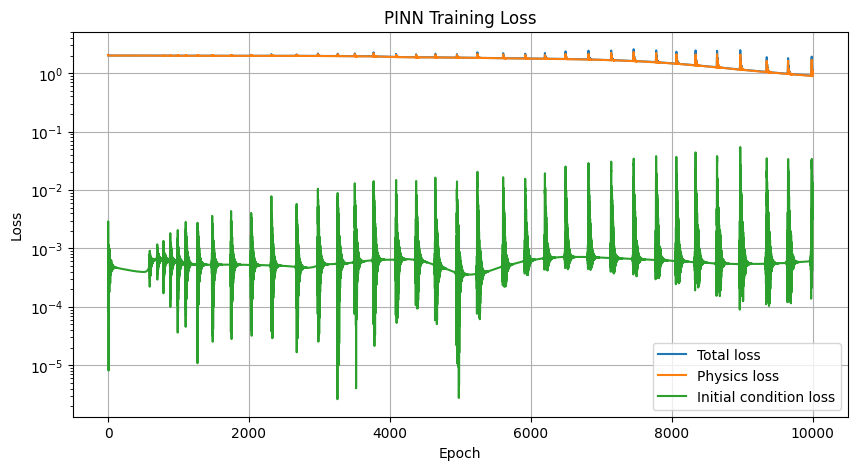

In [20]:
plt.figure(figsize=(10, 5))

plt.semilogy(
    loss_history,
    label="Total loss"
)

plt.semilogy(
    physics_loss_history,
    label="Physics loss"
)

plt.semilogy(
    ic_loss_history,
    label="Initial condition loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("PINN Training Loss")

plt.legend()
plt.grid(True)

plt.show()

In [21]:
# prediction points

tau_test = torch.tensor(
    normalize_time(t_data),
    dtype=torch.float32,
    device=device
).reshape(-1, 1)

tau_test.requires_grad_(True)

# prediction

model.eval()

x_pinn, v_pinn, acceleration_pinn = derivatives(
    model,
    tau_test
)

# detach from PyTorch

x_pinn = x_pinn.detach().cpu().numpy().flatten()
v_pinn = v_pinn.detach().cpu().numpy().flatten()
acceleration_pinn = acceleration_pinn.detach().cpu().numpy().flatten()

In [22]:
# calculate RMSE

rmse = np.sqrt(
    np.mean(
        (x_pinn - x_true) ** 2
    )
)

mse = np.mean(
    (x_pinn - x_true) ** 2
)

print(f"PINN MSE  = {mse:.6e} m²")
print(f"PINN RMSE = {rmse:.6e} m")

PINN MSE  = 2.805287e-01 m²
PINN RMSE = 5.296496e-01 m


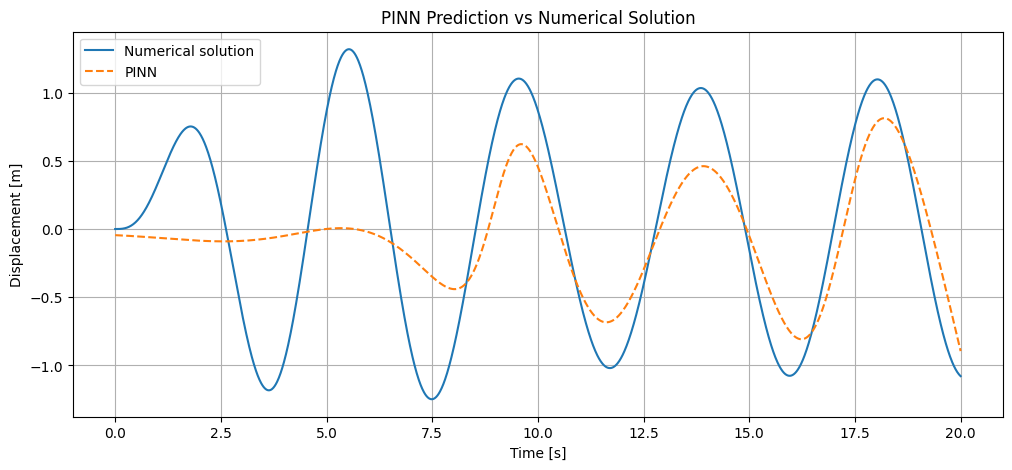

In [23]:
plt.figure(figsize=(12, 5))

plt.plot(
    t_data,
    x_true,
    label="Numerical solution"
)

plt.plot(
    t_data,
    x_pinn,
    "--",
    label="PINN"
)

plt.xlabel("Time [s]")
plt.ylabel("Displacement [m]")

plt.title("PINN Prediction vs Numerical Solution")

plt.legend()
plt.grid(True)

plt.show()

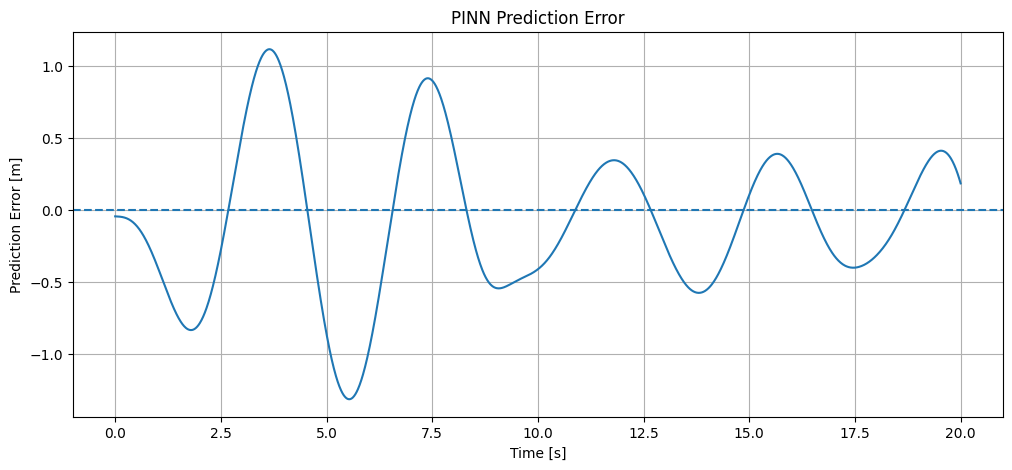

In [24]:
error = x_pinn - x_true

plt.figure(figsize=(12, 5))

plt.plot(
    t_data,
    error
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Time [s]")
plt.ylabel("Prediction Error [m]")

plt.title("PINN Prediction Error")

plt.grid(True)

plt.show()

Mean absolute physics residual: 0.7962051
Maximum absolute physics residual: 2.274029


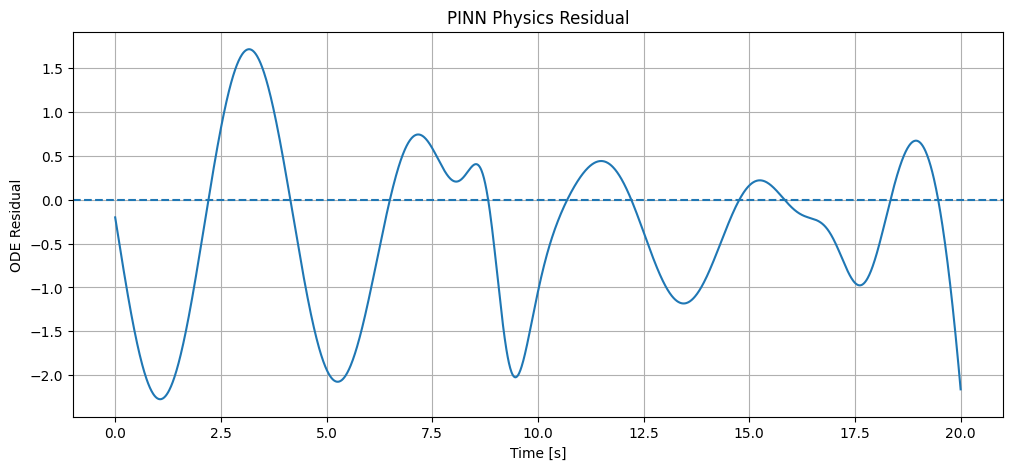

In [25]:
# calculate residual after training

tau_residual = torch.tensor(
    normalize_time(t_data),
    dtype=torch.float32,
    device=device
).reshape(-1, 1)

tau_residual.requires_grad_(True)

residual = physics_residual(
    model,
    tau_residual
)

residual = (
    residual
    .detach()
    .cpu()
    .numpy()
    .flatten()
)

print(
    "Mean absolute physics residual:",
    np.mean(np.abs(residual))
)

print(
    "Maximum absolute physics residual:",
    np.max(np.abs(residual))
)

plt.figure(figsize=(12, 5))

plt.plot(
    t_data,
    residual
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Time [s]")
plt.ylabel("ODE Residual")

plt.title("PINN Physics Residual")

plt.grid(True)

plt.show()

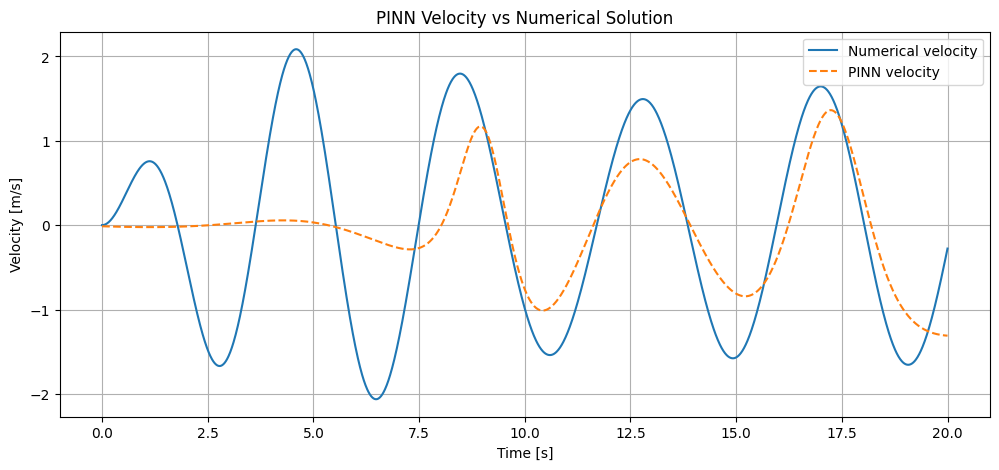

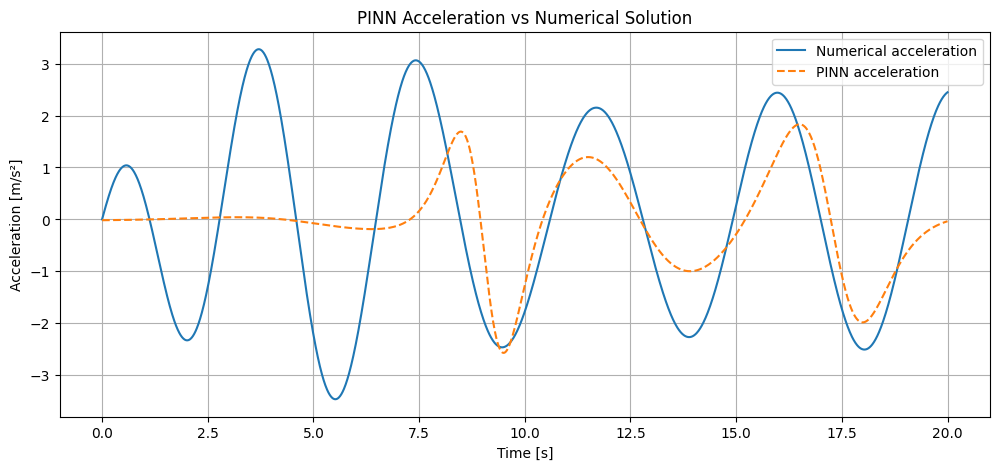

In [26]:
plt.figure(figsize=(12, 5))

plt.plot(
    t_data,
    v_true,
    label="Numerical velocity"
)

plt.plot(
    t_data,
    v_pinn,
    "--",
    label="PINN velocity"
)

plt.xlabel("Time [s]")
plt.ylabel("Velocity [m/s]")

plt.title("PINN Velocity vs Numerical Solution")

plt.legend()
plt.grid(True)

plt.show()

acceleration_true = (
    force_data
    - c * v_true
    - k * x_true
) / m

plt.figure(figsize=(12, 5))

plt.plot(
    t_data,
    acceleration_true,
    label="Numerical acceleration"
)

plt.plot(
    t_data,
    acceleration_pinn,
    "--",
    label="PINN acceleration"
)

plt.xlabel("Time [s]")
plt.ylabel("Acceleration [m/s²]")

plt.title("PINN Acceleration vs Numerical Solution")

plt.legend()
plt.grid(True)

plt.show()

In [27]:
velocity_rmse = np.sqrt(
    np.mean(
        (v_pinn - v_true) ** 2
    )
)

acceleration_rmse = np.sqrt(
    np.mean(
        (acceleration_pinn - acceleration_true) ** 2
    )
)

physics_rmse = np.sqrt(
    np.mean(residual ** 2)
)

print("PINN Performance")
print("----------------------------")
print(f"Displacement RMSE : {rmse:.6e} m")
print(f"Velocity RMSE     : {velocity_rmse:.6e} m/s")
print(f"Acceleration RMSE : {acceleration_rmse:.6e} m/s²")
print(f"Physics RMSE      : {physics_rmse:.6e}")

PINN Performance
----------------------------
Displacement RMSE : 5.296496e-01 m
Velocity RMSE     : 8.465788e-01 m/s
Acceleration RMSE : 1.486116e+00 m/s²
Physics RMSE      : 1.013907e+00


In [28]:
torch.save(
    model.state_dict(),
    "pinn_mass_spring.pt"
)

print("PINN model saved.")

PINN model saved.
